# Check/Extract tll events and create txt file with curated times

Consider for a 30000 Hz sampling rate, the minimum frequency that can be resolved is 34 microseconds

### Imports

In [23]:
import spikeinterface.full as si
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import wavfile

### Functions

In [2]:
def readMeta(binFullPath):
    metaName = binFullPath.stem + ".meta"
    metaPath = Path(binFullPath.parent / metaName)
    metaDict = {}
    if metaPath.exists():
        # print("meta file present")
        with metaPath.open() as f:
            mdatList = f.read().splitlines()
            # convert the list entries into key value pairs
            for m in mdatList:
                csList = m.split(sep='=')
                if csList[0][0] == '~':
                    currKey = csList[0][1:len(csList[0])]
                else:
                    currKey = csList[0]
                metaDict.update({currKey: csList[1]})
    else:
        print("no meta file")
    return(metaDict)
    
def plot_ttl_events(abs_trace, obx_trace_time, times_above):
    # Plot crosssings found - ttl events 
    plt.plot(obx_trace_time, abs_trace);
    plt.xlabel('Time [s]');
    plt.ylabel('Amplitude [V]');
    plt.title(f'Number of ttl events found: {len(times_above)}');

    # Plot crossings
    for ttl in times_above:
        plt.axvline(ttl, color='red', linestyle=':')
    plt.show()

## Define paths and parameters to access data

In [21]:
recording = 'M296_3'
ttl_type = 'obx_stim_pulses'
obx_path = rf'M:\test_Stim_g0'
obx_bin_name = fr'test_Stim_g0_t0.obx0.obx.bin'
ttl_path = fr'M:\test_Stim_g0\test_Stim_g0_imec0\catgt_test_Stim_g0'
ttl_file = None  # Add .txt with ttl_times if available
write_ch2wav = False # Write loaded channel to wav?
ttl_ch = 4 # stim pulse ttl, plb ttl...

### Load data

In [15]:
# Load obx metadata
obx_full_path = Path(obx_path, obx_bin_name)
meta = readMeta(obx_full_path);
sRate = float(meta['obSampRate']);
n_chs = int(meta['nSavedChans'])
maxRange = float(meta['obAiRangeMax'])
gain_factor = maxRange / float(meta['obMaxInt']) # Will give Volts

# Create recording object
obx_rec = si.read_binary(obx_full_path, sampling_frequency=sRate,
    dtype=np.int16, num_channels=n_chs, gain_to_uV=gain_factor, offset_to_uV=0); # Volts, not uV

# Get obx trace and time from desired ttl channel
obx_trace = obx_rec.get_traces(channel_ids=[ttl_ch], return_in_uV=True).flatten()
obx_trace_time = obx_rec.get_times()

# Save ttl loaded channel as wav if needed, helps identifying ttls
if write_ch2wav: 
    # Get data in int format so it doesnt clip
    audio_data = obx_rec.get_traces(channel_ids=[ttl_ch]).flatten()
    save_full_path = Path(ttl_path, f'{recording}_{ttl_type}_ch{ttl_ch}.wav')
    wavfile.write(save_full_path, int(sRate), audio_data)

### Get ttl event times

In [7]:
## Load/Find ttl events
if ttl_file is None:
    # Find 
    threshold = 1; # Volts
    abs_trace = abs(obx_trace) # Get rid of negative values
    above_threshold = abs_trace > threshold; # Find indices where th is crossed
    times_above = obx_trace_time[above_threshold] # Get times where th is crossed
    rising_times = times_above.copy()
else:
    ttl_full_path = Path(ttl_path, ttl_file)
    times_above = np.loadtxt(ttl_full_path)
    rising_times = times_above.copy()

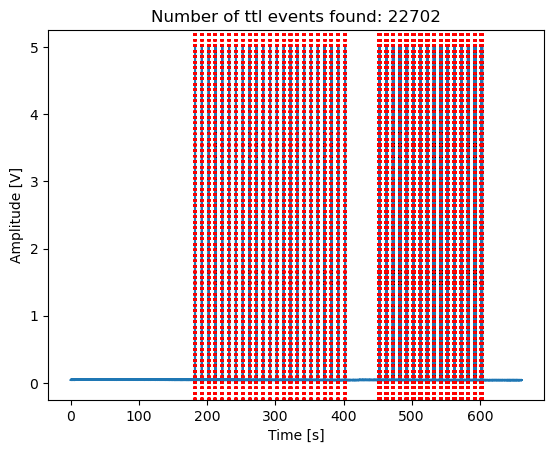

In [8]:
# Plot crosssings found - ttl events 
plot_ttl_events(abs_trace, obx_trace_time, rising_times)

### Extra thresholding - gap time between simuli

In [9]:
# Write expected gap_time in seconds
gap_time = 0.005 # 5ms

In [10]:
# When previous procedure is not enough, consider gap time between stimuli
time_diffs = np.diff(times_above)
gap_indices = np.where(time_diffs > gap_time)[0] + 1 # +1 shifts to the start of the new pulse
rising_times = np.insert(times_above[gap_indices], 0, times_above[0])

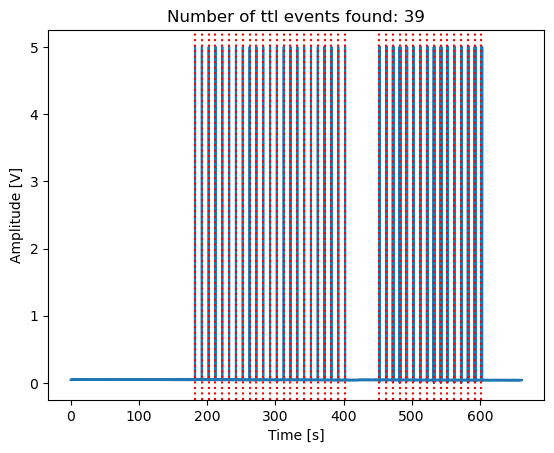

In [11]:
# Plot crosssings found - ttl events 
plot_ttl_events(abs_trace, obx_trace_time, rising_times)

### Save txt file with curated ttl event times

In [35]:
save_full_path = Path(ttl_path, f'{recording}_{ttl_type}_seconds.txt')
np.savetxt(save_full_path, rising_times, fmt='%.6f')

FIN